In [28]:
import pandas as pd

In [29]:
df = pd.read_csv("/content/OnlineNewsPopularity.csv")

In [30]:
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [31]:
df.shape

(39644, 61)

In [32]:
df.columns

Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sent

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [34]:
df = df.drop('url', axis=1)

In [35]:
x = df.drop(' shares', axis=1)
y = df[' shares']

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [38]:
x_train.shape

(31715, 59)

In [39]:
x_test.shape

(7929, 59)

In [40]:
y_train.shape

(31715,)

In [41]:
y_test.shape

(7929,)

In [42]:
import numpy as np

In [43]:
y_train =  np.log1p(y_train)
y_test = np.log1p(y_test)

In [44]:
scaler = StandardScaler()

In [45]:
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [46]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [47]:
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(x_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='linear') #output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [49]:
early_Stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=13-6)

In [50]:
from sklearn.metrics import r2_score

In [51]:
from tensorflow.keras import backend as k

In [52]:
def r2_score_custom(y_true, y_pred):
  y_true = k.cast(y_true, 'float32')
  ss_res = k.sum(k.square(y_true - y_pred))
  ss_tot = k.sum(k.square(y_true - k.mean(y_true)))
  return (1 - ss_res/(ss_tot + k.epsilon()))

In [53]:
model.compile(optimizer='adam', loss='mse', metrics=['mae', r2_score_custom])

In [54]:
history = model.fit(x_train, y_train,
                    epochs=100, batch_size=128,
                    validation_data=(x_test, y_test),
                    callbacks=[early_Stop, reduce_lr])

Epoch 1/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 12.0013 - mae: 2.4975 - r2_score_custom: -13.4941 - val_loss: 3.3685 - val_mae: 1.0467 - val_r2_score_custom: -2.8475 - learning_rate: 0.0010
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.3950 - mae: 0.9090 - r2_score_custom: -0.6571 - val_loss: 8.1266 - val_mae: 0.8214 - val_r2_score_custom: -9.2050 - learning_rate: 0.0010
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2942 - mae: 0.8742 - r2_score_custom: -0.5364 - val_loss: 0.9305 - val_mae: 0.6826 - val_r2_score_custom: -0.0919 - learning_rate: 0.0010
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.2480 - mae: 0.8562 - r2_score_custom: -0.4659 - val_loss: 1.0792 - val_mae: 0.7092 - val_r2_score_custom: -0.2649 - learning_rate: 0.0010
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.2151 - mae: 0.8481 - r2_score_custom: -0.4261 - val_loss: 0.9682 - val_mae: 0.7071 - val_r2_score_custom: -0.1373 - learning_rate

In [55]:
import matplotlib.pyplot as plt

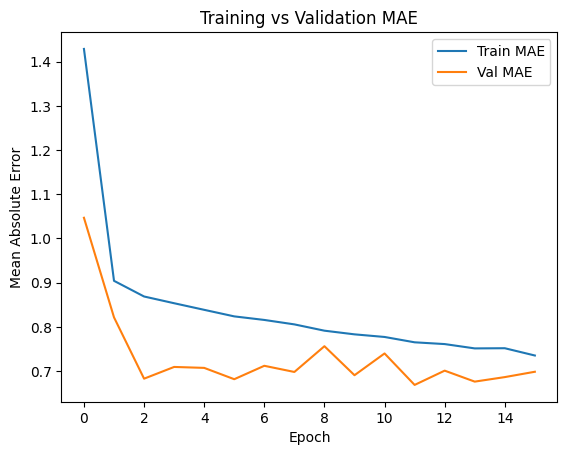

In [56]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs Validation MAE')
plt.show()

In [57]:
y_pred = model.predict(x_test)

248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [58]:
r2_score(y_test, y_pred)

-0.013724202882200442

In [59]:
# y_pred = model.predict(x_test).flatten()

In [60]:
# r2_score(np.expm1(y_test), np.expm1(y_pred))

In [61]:
from sklearn.metrics import mean_absolute_error

In [62]:
mean_absolute_error(y_test, y_pred)

0.6814376916017711

In [63]:
# mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

# **Denoising Autoencoder (DAE)**

## 📝 Task: Build a Simple Autoencoder for Noisy Data

## Objective
The dataset you are working with already contains a lot of **noise**.  
Your task is to build a **simple Autoencoder** that learns a cleaner representation of the features and produces latent features for downstream tasks.

---

## Steps

### 1️⃣ Prepare Data
- Use `X_train` and `X_test` directly.
- Ensure the input shape matches the number of features.

💡 *Hint: you can check it with `X_train.shape[1]`.*

---

### 2️⃣ Build Autoencoder
- Input layer = number of features.
- Encoder: one hidden dense layer (e.g., 64 units, ReLU).
- Decoder: one dense layer that reconstructs the input (linear activation).

💡 *Hint: Encoder reduces the dimensionality, Decoder reconstructs the original features.*

---

### 3️⃣ Train Autoencoder
- Train the model to reconstruct the inputs.
- Use `"mse"` loss and `"adam"` optimizer.
- Train for ~20 epochs, batch size 128.
- Validate on `(X_test, X_test)`.

💡 *Hint: the target is the same as the input (`X_train → X_train`).*

---

### 4️⃣ Extract Encoder
- Define a new model that outputs the **encoded layer** only.
- Transform `X_train` and `X_test` into latent features (`Z_train`, `Z_test`).

💡 *Hint: `encoder = Model(inputs, encoded_layer)`.*

---

## Deliverables
- Training and validation loss curve (plot).
- Latent features: print shape of `Z_train` and `Z_test`.
- Short reflection: *Do latent features seem more compact/cleaner than raw inputs?*


In [68]:
input_dim = X_train.shape[1]
encoding_dim = 8  # You can tune this value

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [74]:
history = autoencoder.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1,
    callbacks=[early_Stop, reduce_lr]
)

Epoch 1/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.5170 - val_loss: 56.5112 - learning_rate: 0.0010
Epoch 2/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7974 - val_loss: 57.0339 - learning_rate: 0.0010
Epoch 3/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7709 - val_loss: 57.2790 - learning_rate: 0.0010
Epoch 4/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7764 - val_loss: 56.9884 - learning_rate: 0.0010
Epoch 5/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7915 - val_loss: 58.1650 - learning_rate: 0.0010
Epoch 6/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7743 - val_loss: 57.4793 - learning_rate: 0.0010
Epoch 7/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7796 - val_loss: 57.5978 - learning_rate: 0.0010
Epoch 8/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7569 - val_loss: 56.1319 - learning_rate: 0.0010
Epoch 9/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7711 - val_loss: 56.2212 - learning_rate: 0.0010
E

In [75]:
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.square(X_test - reconstructions), axis=1)

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [76]:
threshold = np.percentile(mse, 95)
anomalies = mse > threshold

In [77]:
print(f"Number of anomalies detected: {np.sum(anomalies)}")

Number of anomalies detected: 397


In [78]:
encoder = Model(inputs=input_layer, outputs=encoded)

Z_train = encoder.predict(X_train)
Z_test = encoder.predict(X_test)

print("Shape of Z_train:", Z_train.shape)
print("Shape of Z_test:", Z_test.shape)

992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Shape of Z_train: (31715, 8)
Shape of Z_test: (7929, 8)
